# Γ ramps without and with a Γ_CO₂-scaled internal-variability term (GLS)

Thin wrapper around `gamma_gls.py` (GLS noise models), `gamma_model.py` (design, scenarios) and `gamma_plot.py`.

**Model:** $T_t = \Gamma_{CO_2}\ln(c_t/278.3) + \Gamma_{SAI}\,\Delta T\,(\min(t,50)/50)^z + \text{noise}_t$, with $t = 1$ in 2026. Two noise models are compared:

| model | noise | Σ |
|---|---|---|
| `white` (gamma_ramps) | $\varepsilon_t$ | $\sigma^2 I$ |
| `iv` | $\varepsilon_t + \Gamma_{CO_2}(L_{eff}/f)\,q_t$ | $\sigma^2 I + (\Gamma_{CO_2}L_{eff}/f)^2\,\mathrm{Var}(q)\,R(\rho)$ |

Here $q_t = \rho q_{t-1} + \sigma_{IV} w_t$ is AR(1); **σ_IV is the innovation std**, so Var$(q)=\sigma_{IV}^2/(1-\rho^2)$.

Both models are fit by **GLS with Σ known**: Cov$= (X^\top\Sigma^{-1}X)^{-1}$, exact at every N. For `white` this is OLS.
The true Γ_CO₂ enters only through Σ, by setting the IV amplitude. GLS does *not* exploit the information
the fluctuation size carries about Γ_CO₂; for the Cramér–Rao bound that includes it, see `gammaiv`.

No install needed: run this notebook from `conceptual/` so the modules import directly.

In [1]:
%load_ext autoreload
%autoreload 2
from dataclasses import replace
from pathlib import Path

import numpy as np
import gamma_gls as gg
import gamma_model as gm
import gamma_plot as gp

## 1. Configuration

In [2]:
CSV, STAT = "../data/input/scenariomip7_conc_paths.csv", "median"
FIG_DIR = Path("../analysis/figs/conceptual")   # figure/output directory
FIG_DIR.mkdir(parents=True, exist_ok=True)
P = gg.NoiseParams(sigma=0.3, G=1.6 * 4.9 / 2.2896, sig_IV=0.09, rho=0.2, L_eff=2.2896, f=4.9)
Z_VALUES = [1/3, 1, 3]
DELTA_T = [0.5, 1.0]
DESIGN = dict(t_ref=50.0, t_cap=50.0)   # t_cap=None removes the 2075 plateau
print(f"IV term marginal std = {P.iv_std:.3f} (white std = {P.sigma})")

IV term marginal std = 0.147 (white std = 0.3)


## 2. Compute

In [3]:
scen = gm.load_scenarios(CSV, STAT, 2026, 2100)
df = gg.se_table(scen, Z_VALUES, DELTA_T, P, **DESIGN)
rat = gg.ratio_table(df)
df.head()

,model,variant,scenario,z,delta_T,N,year,se_co2,se_sai,corr,se_co2_rel,se_sai_rel
0,white,no IV (gammaramps),high-extension / high-overshoot,0.333333,0.5,5,2030,1.949700,4.381247,-0.987333,1.000000,1.000000
1,white,no IV (gammaramps),high-extension / high-overshoot,0.333333,0.5,6,2031,1.709648,3.677223,-0.986439,0.876877,0.839310
2,white,no IV (gammaramps),high-extension / high-overshoot,0.333333,0.5,7,2032,1.540841,3.193263,-0.985867,0.790296,0.728848
3,white,no IV (gammaramps),high-extension / high-overshoot,0.333333,0.5,8,2033,1.415057,2.840025,-0.985522,0.725782,0.648223
4,white,no IV (gammaramps),high-extension / high-overshoot,0.333333,0.5,9,2034,1.317473,2.571051,-0.985342,0.675731,0.586831


## 3. Figures
### (a) No IV: the gamma_ramps figure

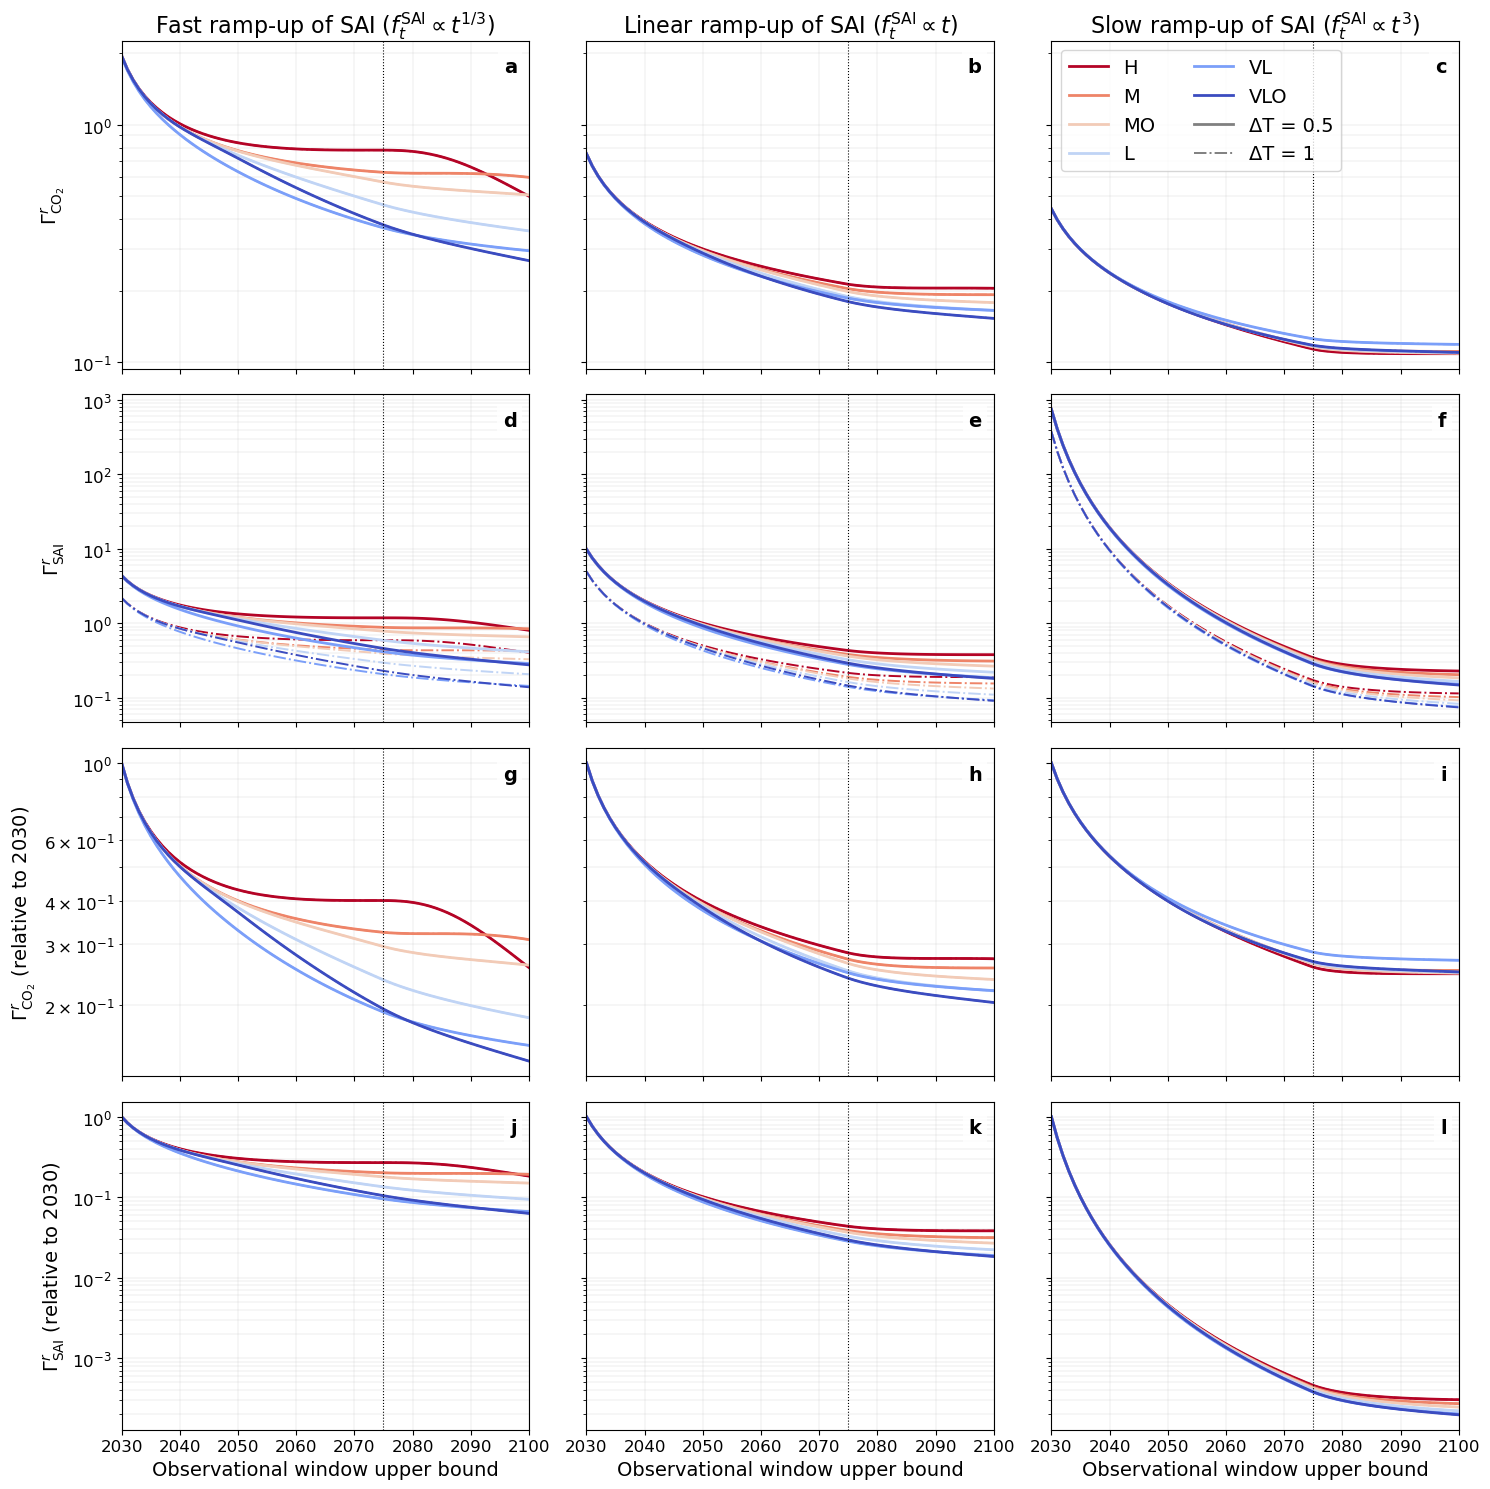

In [4]:
fig, ax = gp.plot_se_grid(df[df.model == "white"])
fig.savefig(FIG_DIR / "gamma_white.png", dpi=150)

### (b) With IV, GLS: same layout

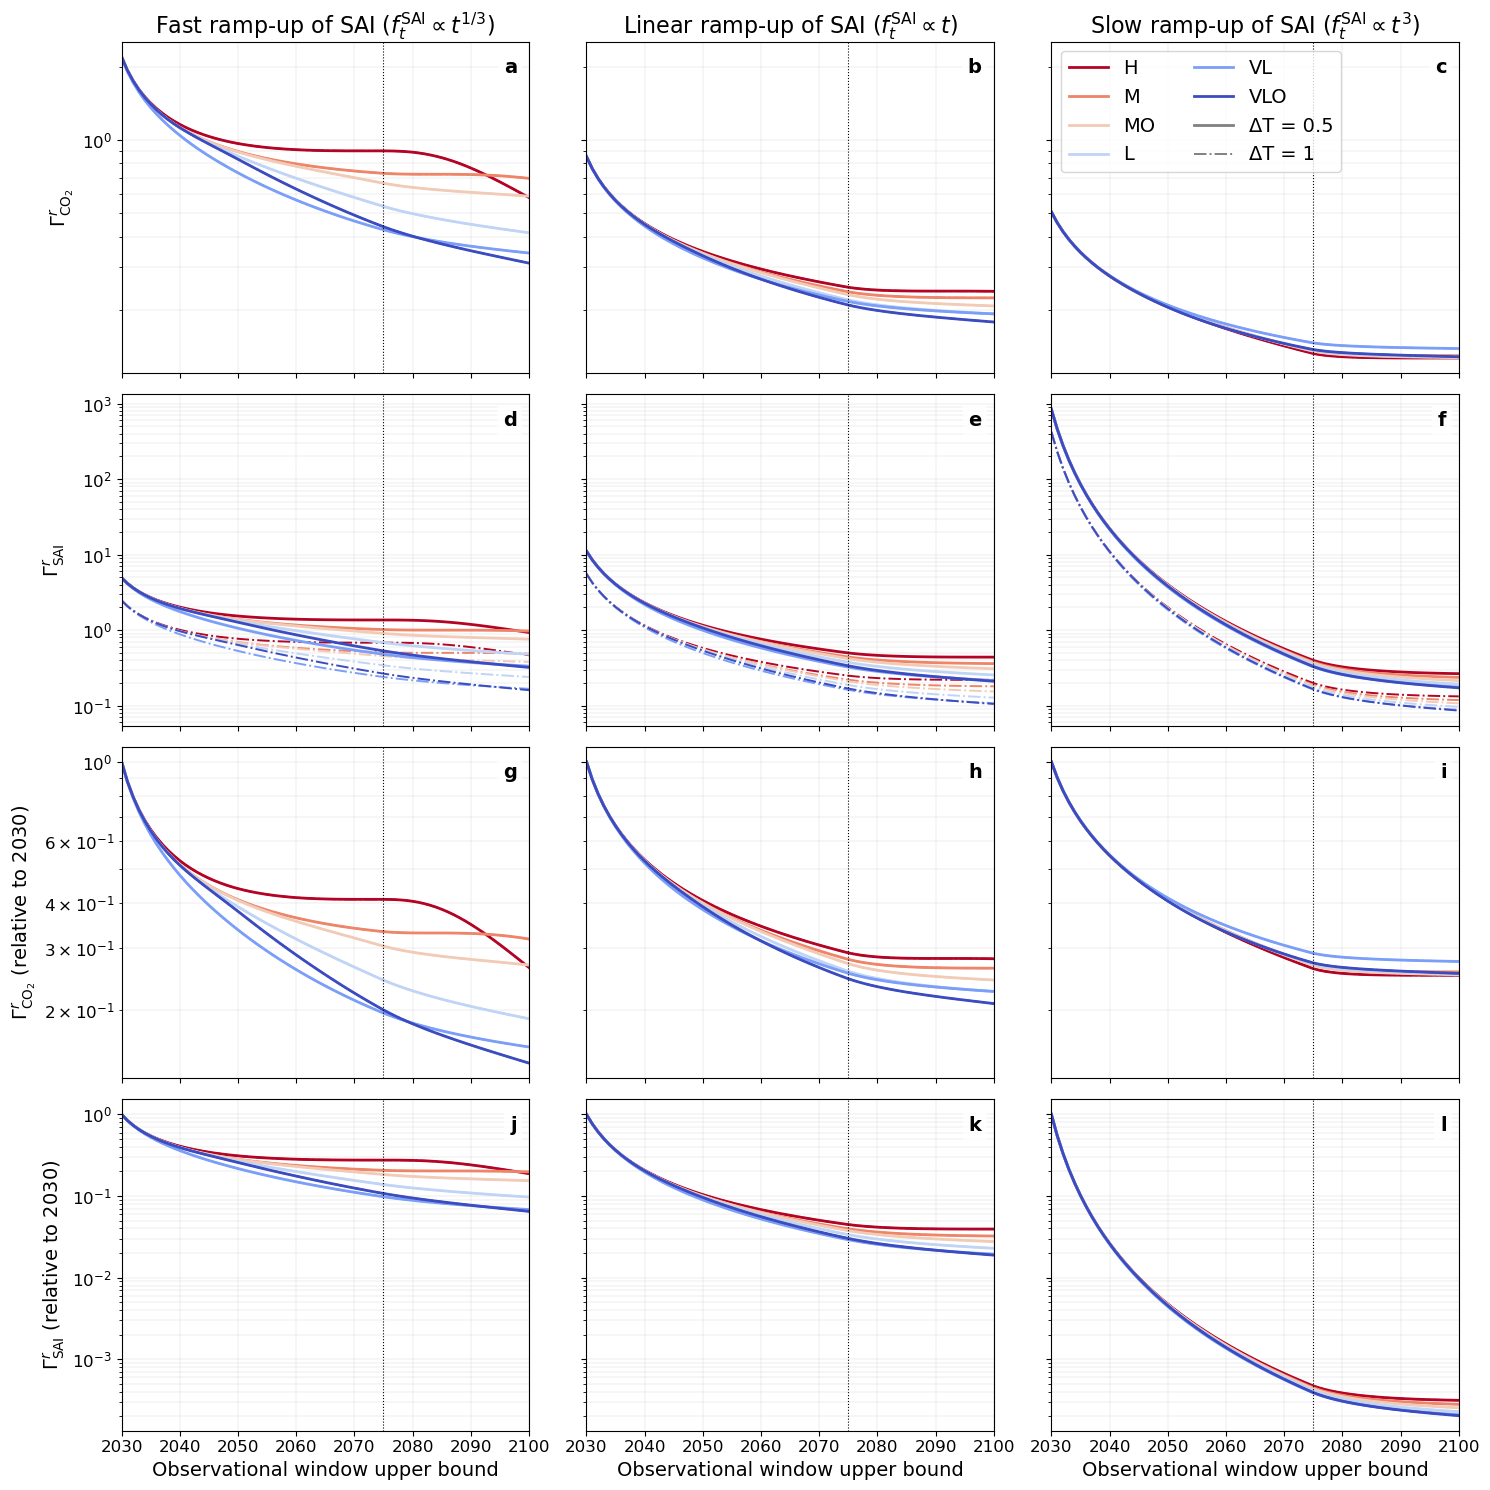

In [5]:
fig, ax = gp.plot_se_grid(df[df.model == "iv"])
fig.savefig(FIG_DIR / "gamma_iv_gls.png", dpi=150)

### (c) Overlay (ΔT = 0.5): solid = no IV, dash-dot = IV, GLS

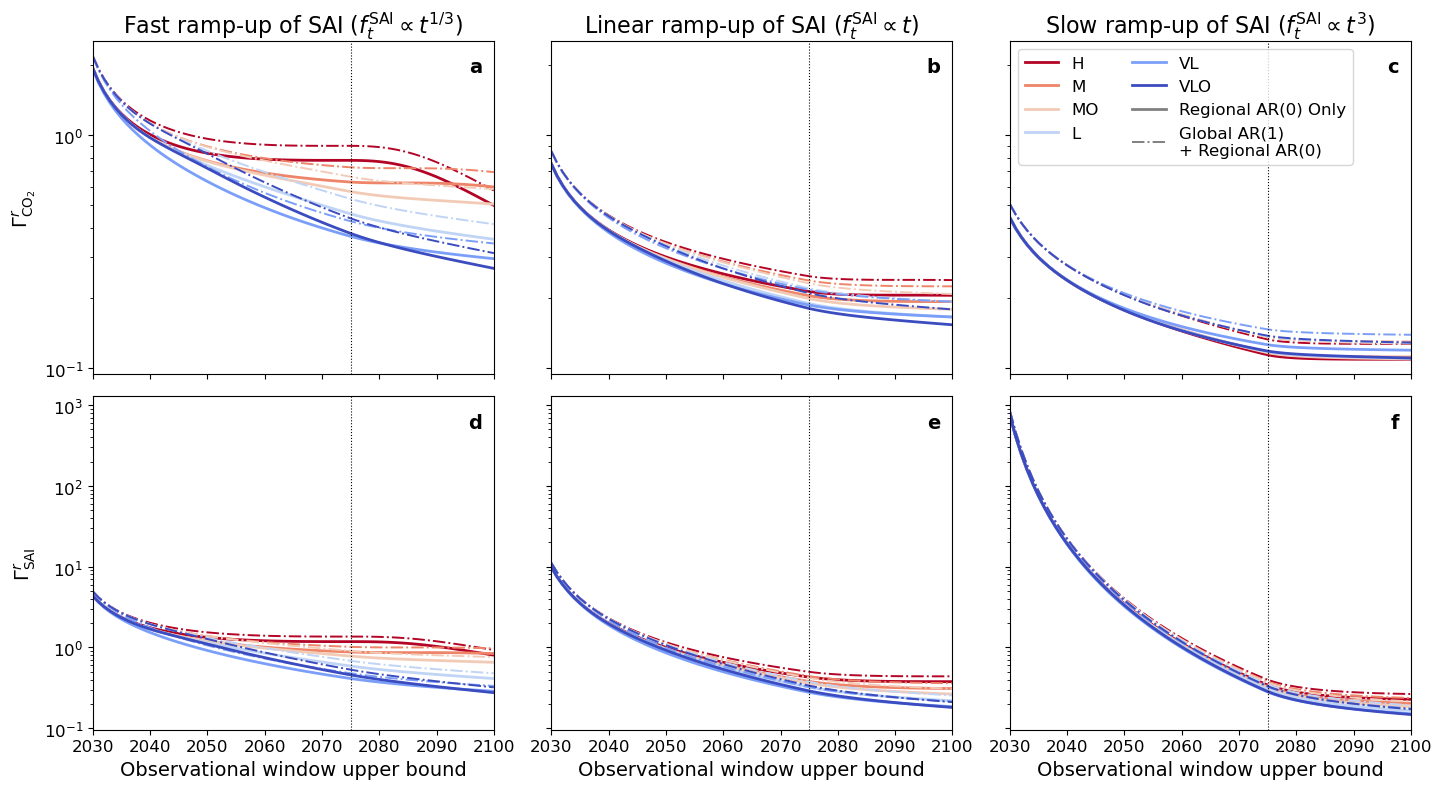

In [15]:
fig, ax = gp.plot_se_grid(df[df.delta_T == 0.5], style="variant", rows=gp.DEFAULT_ROWS[:2], figsize=(15, 8))

# edit legend
h, l = ax[0, 2].get_legend_handles_labels()
l[-2:] = ["Regional AR(0) Only", "Global AR(1)\n+ Regional AR(0)"]
ax[0, 2].legend(h, l, loc='upper left', fontsize=12, ncol=2)

# save
fig.savefig(FIG_DIR / "gamma_overlay.png", dpi=350)

### (d) Ratio SE(IV, GLS) / SE(no IV)
This is the same for both ΔT values, because ΔT cancels.

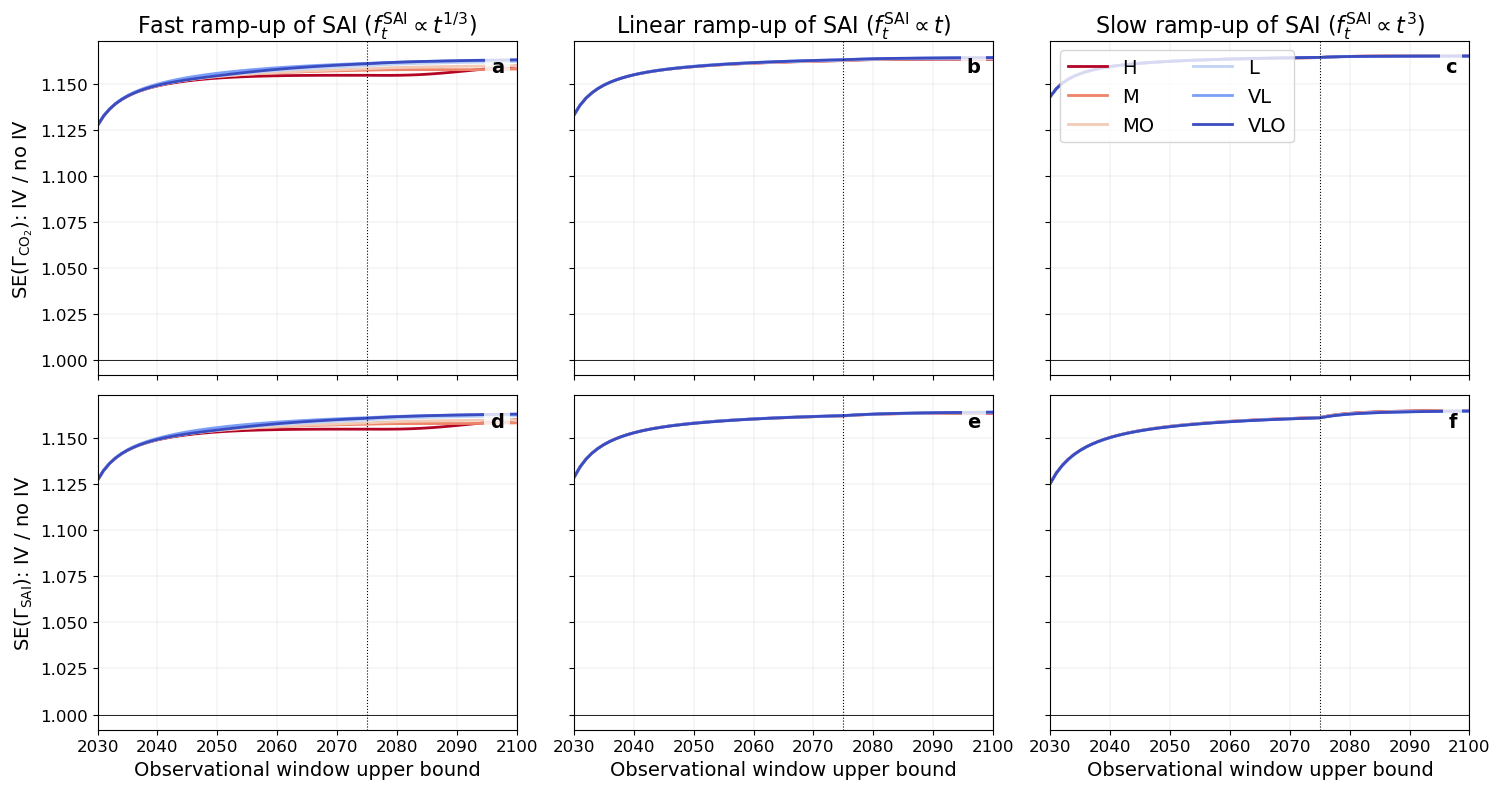

In [7]:
rows = [("ratio_co2", r"SE($\Gamma_{\mathrm{CO_2}}$): IV / no IV"), ("ratio_sai", r"SE($\Gamma_{\mathrm{SAI}}$): IV / no IV")]
fig, ax = gp.plot_se_grid(rat[rat.delta_T == DELTA_T[0]], style=None, rows=rows, logy=False, figsize=(15, 8))
for a in ax.flat:
    a.axhline(1, c="k", lw=0.6)
fig.savefig(FIG_DIR / "gamma_ratio.png", dpi=150)

In [8]:
# Ratio in the 2100 window
rat[(rat.N == 75) & (rat.delta_T == DELTA_T[0])].pivot_table(index="scenario", columns="z", values="ratio_co2").round(3)

z,0.333333,1.000000,3.000000
scenario,,,
high-extension / high-overshoot,1.160,1.163,1.165
low,1.162,1.164,1.165
medium-extension,1.158,1.164,1.165
medium-overshoot,1.160,1.164,1.165
verylow,1.163,1.164,1.165
verylow-overshoot,1.163,1.164,1.165


## 4. Plotting knobs
`plot_se_grid(df, hue="scenario", style="delta_T" | "variant" | None, rows=..., columns=..., hue_order=..., colors=..., styles=..., sharey=..., logy=..., cap_year=..., legend_ax=..., legend_loc=..., figsize=...)` draws only; it never recomputes.

## 5. Sensitivity of the IV penalty
Example: ρ and σ_IV for one scenario at z = 1, in the 2100 window.

In [ ]:
c = gm.concentration_ratio(scen["verylow-overshoot"], 75)
for rho in [0.2, 0.5, 0.8]:
    for sig_IV in [0.09, 0.2]:
        p = replace(P, rho=rho, sig_IV=sig_IV)
        w = gg.gamma_standard_errors(c, 1.0, 0.5, p, "white"); v = gg.gamma_standard_errors(c, 1.0, 0.5, p, "iv")
        print(f"rho={rho}, sig_IV={sig_IV}: IV std={p.iv_std:.3f}  SE ratio CO2={v[0]/w[0]:.3f}, SAI={v[1]/w[1]:.3f}")